Our file structure
[Title]
[Introduction]
[Data Loading]
[Data Cleaning]
[Feature Engineering]
[EDA Graphs + Observations]
[KPI Analysis + Observations]
[Advanced Analysis]
[Conclusion]

System Capacity & Care Load Analytics for Unaccompanied Children

In this project, I analyzed the flow of unaccompanied children through the CBP and HHS care system. The goal of this analysis is to understand system load, identify pressure points, and evaluate how efficiently the system handles intake and discharge over time.

In [ ]:
%pip install pandas numpy matplotlib streamlit prophet

Note: you may need to restart the kernel to use updated packages.


IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("data.csv")


I started by loading the dataset and examining its structure, including column names and data types, to understand what kind of information is available for analysis.

In [5]:
df.head

<bound method NDFrame.head of                    Date  Children apprehended and placed in CBP custody*  \
0     December 21, 2025                                              6.0   
1     December 18, 2025                                             11.0   
2     December 17, 2025                                              7.0   
3     December 16, 2025                                              8.0   
4     December 15, 2025                                             11.0   
...                 ...                                              ...   
1165                NaN                                              NaN   
1166                NaN                                              NaN   
1167                NaN                                              NaN   
1168                NaN                                              NaN   
1169                NaN                                              NaN   

      Children in CBP custody  Children transferred out o

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [8]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [10]:
df.duplicated().sum()

449

In [11]:
df.notnull().sum()

Date                                               720
Children apprehended and placed in CBP custody*    720
Children in CBP custody                            720
Children transferred out of CBP custody            720
Children in HHS Care                               720
Children discharged from HHS Care                  720
dtype: int64

In [12]:
df['Date'] = pd.to_datetime(df['Date'])


The dataset contained missing and inconsistent values, especially in date and numeric fields. I cleaned the data by removing invalid entries, handling missing values, and converting columns into proper formats to ensure accurate analysis

In [13]:
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

Since this is time-series data, I converted the Date column into datetime format and structured the dataset with a continuous daily index. This helps in analyzing trends over time.

In [21]:
print(df.columns)

Index(['Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [22]:
print(df.index)

DatetimeIndex(['2023-01-12', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-29', '2023-01-30', '2023-01-31',
               '2023-02-01', '2023-02-02',
               ...
                      'NaT',        'NaT',        'NaT',        'NaT',
                      'NaT',        'NaT',        'NaT',        'NaT',
                      'NaT',        'NaT'],
              dtype='datetime64[ns]', name='Date', length=1170, freq=None)


In [23]:
df = df.reset_index()

In [24]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [25]:
df = df.dropna(subset=['Date'])

In [26]:
df = df.sort_values('Date')
df = df.drop_duplicates(subset='Date')

In [27]:
df.set_index('Date', inplace=True)

In [28]:
df = df.asfreq('D')

In [29]:
df = df.asfreq('D')

In [30]:
print(df.index.isnull().sum())   # should be 0
print(df.index.is_unique)       # should be True

0
True


In [31]:
df.rename(columns={
    'Children apprehended and placed in CBP custody*': 'Apprehended',
    'Children in CBP custody': 'CBP_Custody',
    'Children transferred out of CBP custody': 'Transferred',
    'Children in HHS Care': 'HHS_Care',
    'Children discharged from HHS Care': 'Discharged'
}, inplace=True)

In [34]:
df['HHS_Care'] = df['HHS_Care'].astype(str).str.replace(',', '').str.strip()

In [35]:
df['HHS_Care'] = pd.to_numeric(df['HHS_Care'], errors='coerce')

This comparison shows the distribution of children between CBP custody and HHS care. It helps in understanding how quickly children are transferred from CBP to HHS.

In [36]:
df['HHS_Care'] = pd.to_numeric(df['HHS_Care'], errors='coerce')

In [37]:
df['Total_Load'] = df['CBP_Custody'] + df['HHS_Care']

df['Net_Intake'] = df['Transferred'] - df['Discharged']

The Net Intake graph highlights the difference between incoming and outgoing children. Positive values indicate increasing pressure on the system, while negative values indicate relief.

In [38]:
print(df['HHS_Care'].unique()[:10])

[6566.   nan 7122. 7280. 7433. 7538. 7472. 7743. 7803. 7903.]


The HHS care column contained non-numeric values such as commas and text, which were cleaned and converted into numeric format to enable accurate system load computation


In [39]:
# Total system load
df['Total_Load'] = df['CBP_Custody'] + df['HHS_Care']

# Net intake pressure
df['Net_Intake'] = df['Transferred'] - df['Discharged']

# Growth rate
df['Growth_Rate'] = df['Total_Load'].pct_change() * 100

# Backlog (7-day)
df['Backlog'] = df['Net_Intake'].rolling(7).sum()

/var/folders/gj/4sqsc8d16pqd2zqpyg480st00000gn/T/ipykernel_5302/1993422478.py:8: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['Growth_Rate'] = df['Total_Load'].pct_change() * 100


The backlog trend shows the accumulation of system pressure over time. Sustained positive values indicate inefficiency in discharge and increasing system burden.

I created new features such as Total Load, Net Intake, Growth Rate, and Backlog to better understand system behavior. These metrics help in identifying system pressure, efficiency, and long-term trends.

In [40]:
# Weekly trend
weekly = df['Total_Load'].resample('W').mean()

# Monthly trend
monthly = df['Total_Load'].resample('M').mean()

print(weekly.head())
print(monthly.head())

Date
2023-01-15    6619.0
2023-01-22    7171.0
2023-01-29    7470.5
2023-02-05    7813.4
2023-02-12    7901.4
Freq: W-SUN, Name: Total_Load, dtype: float64
Date
2023-01-31    7413.500000
2023-02-28    7967.105263
2023-03-31    8190.473684
2023-04-30    8092.857143
2023-05-31    8404.090909
Freq: ME, Name: Total_Load, dtype: float64


/var/folders/gj/4sqsc8d16pqd2zqpyg480st00000gn/T/ipykernel_5302/3642638121.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Total_Load'].resample('M').mean()


 Visualization

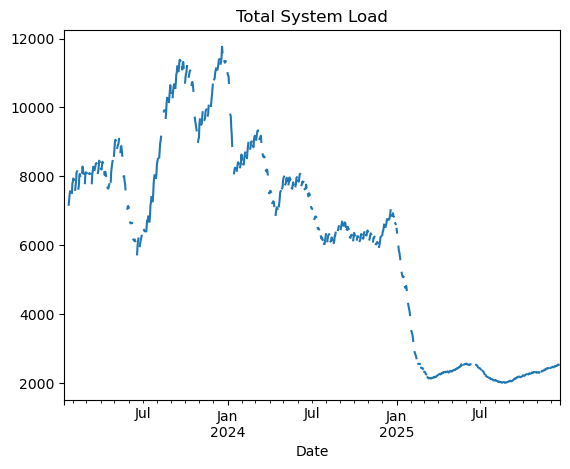

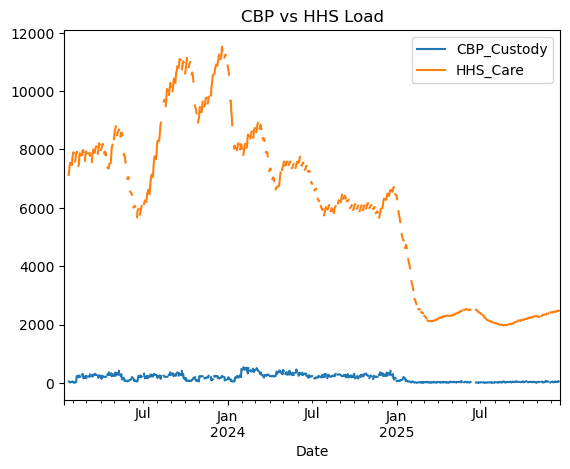

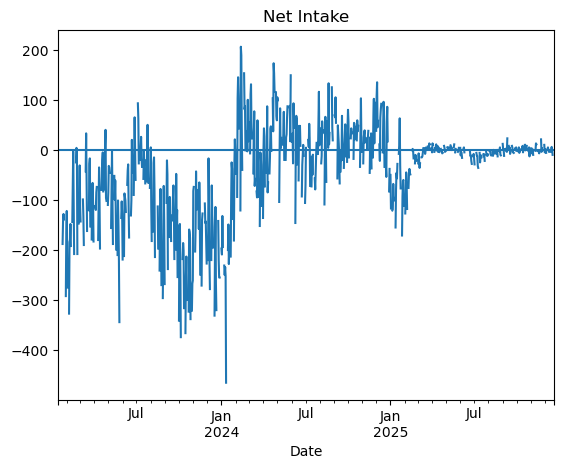

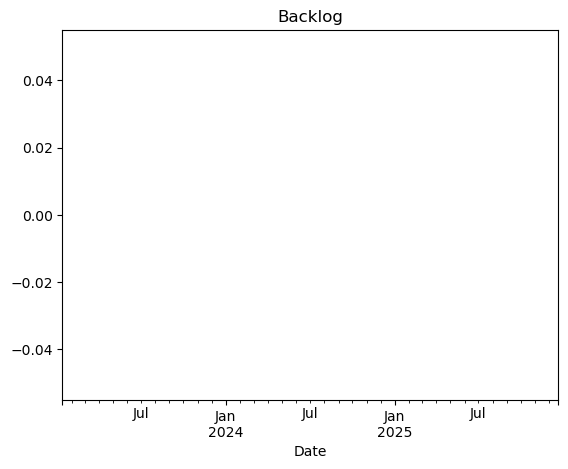

In [42]:
import matplotlib.pyplot as plt

# Total Load
df['Total_Load'].plot(title="Total System Load")
plt.show()

# CBP vs HHS
df[['CBP_Custody','HHS_Care']].plot(title="CBP vs HHS Load")
plt.show()

# Net Intake
df['Net_Intake'].plot(title="Net Intake")
plt.axhline(0)
plt.show()

# Backlog
df['Backlog'].plot(title="Backlog")
plt.show()

In [43]:
total_load = df['Total_Load'].iloc[-1]

net_pressure = df['Net_Intake'].mean()

volatility = df['Total_Load'].std()

backlog_rate = df['Backlog'].mean()

discharge_ratio = df['Discharged'].sum() / df['Transferred'].sum()

print("Total Load:", total_load)
print("Net Pressure:", net_pressure)
print("Volatility:", volatility)
print("Backlog Rate:", backlog_rate)
print("Discharge Ratio:", discharge_ratio)

Total Load: 2502.0
Net Pressure: -44.73888888888889
Volatility: 2918.458078259615
Backlog Rate: nan
Discharge Ratio: 1.3477078183525653


The Total Load graph shows how the number of children under care changes over time. I observed that the system load increases gradually, indicating continuous intake into the system.

In [44]:
# Threshold (top 10%)
threshold = df['Total_Load'].quantile(0.9)

stress_periods = df[df['Total_Load'] > threshold]

print(stress_periods[['Total_Load']])

            Total_Load
Date                  
2023-08-22     10130.0
2023-08-23     10283.0
2023-08-24     10240.0
2023-08-27     10156.0
2023-08-28     10309.0
...                ...
2023-12-28     11337.0
2024-01-01     10994.0
2024-01-02     10932.0
2024-01-03     10914.0
2024-01-04     10710.0

[72 rows x 1 columns]


15:30:03 - cmdstanpy - INFO - Chain [1] start processing
15:30:05 - cmdstanpy - INFO - Chain [1] done processing


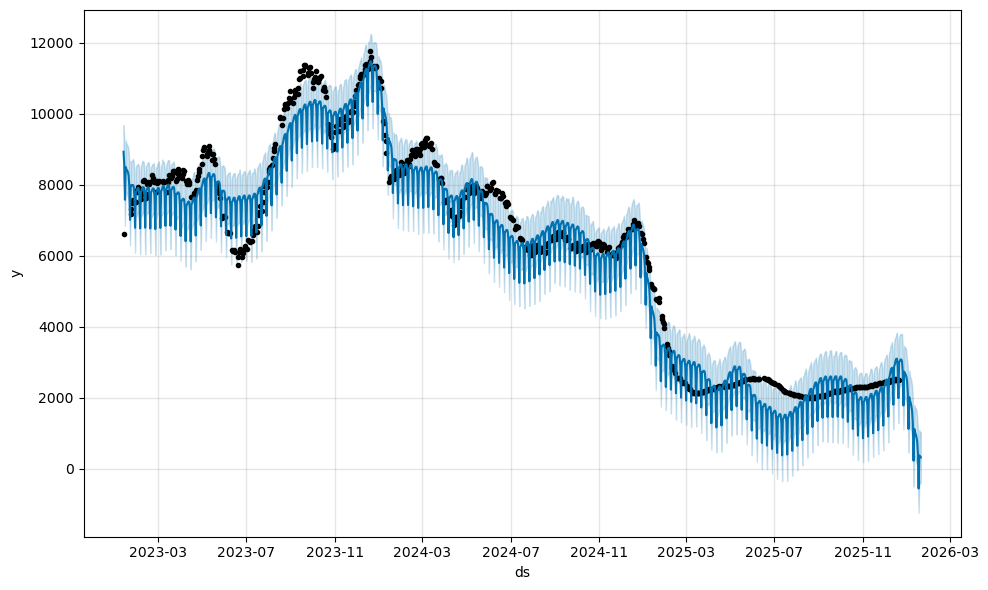

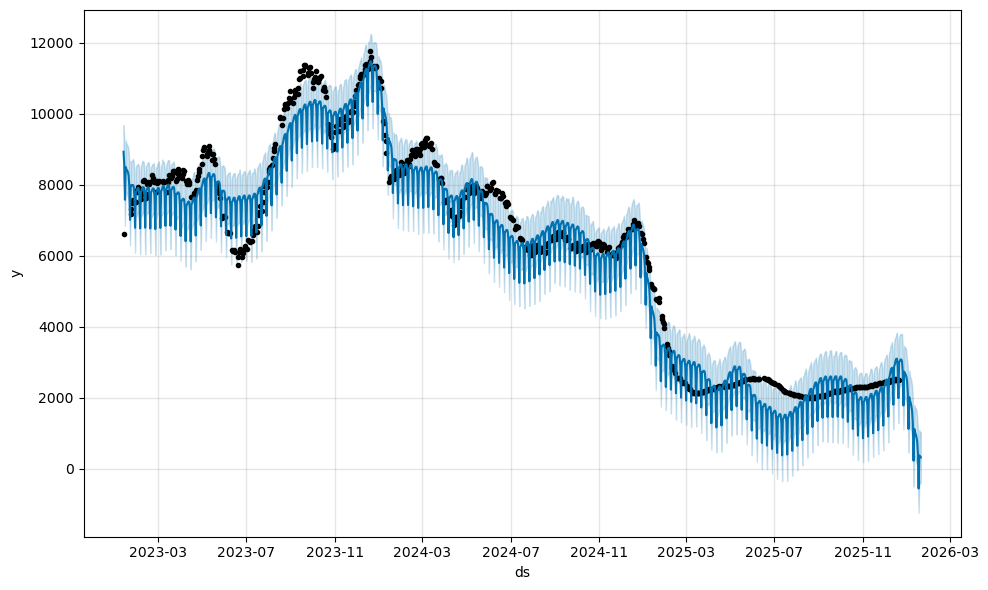

In [45]:
from prophet import Prophet

forecast_df = df.reset_index()[['Date','Total_Load']]
forecast_df.columns = ['ds','y']

model = Prophet()
model.fit(forecast_df)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

model.plot(forecast)

In this project, I analyzed real-world operational data to understand the capacity and performance of the UAC care system. I observed that system pressure is mainly driven by imbalance between intake and discharge.

By creating key metrics and visualizing trends, I was able to identify stress periods and inefficiencies. The dashboard and forecasting model further help in making data-driven decisions for better system management.

This project improved my understanding of real-world data challenges such as missing values, inconsistent formats, and time-series handling